<a href="https://colab.research.google.com/github/arodavidgeo28ad-max/CUSTOMER-CHATBOT-INTERN-PROJECT-/blob/main/ML_15th_EX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (569, 30)

Cross-Validation Results:
Logistic Regression: Mean=0.9737, Std=0.0214
Decision Tree: Mean=0.9099, Std=0.0346
SVM: Mean=0.9759, Std=0.0152
Random Forest: Mean=0.9647, Std=0.0317

Test Set Evaluation:

Logistic Regression
Accuracy: 0.9736842105263158
Confusion Matrix:
 [[41  2]
 [ 1 70]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Decision Tree
Accuracy: 0.9385964912280702
Confusion Matrix:
 [[39  4]
 [ 3 68]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.91      0.92        43
           1       0.94      0.96      0.95        71

    accuracy                           0.94       114
   macro av

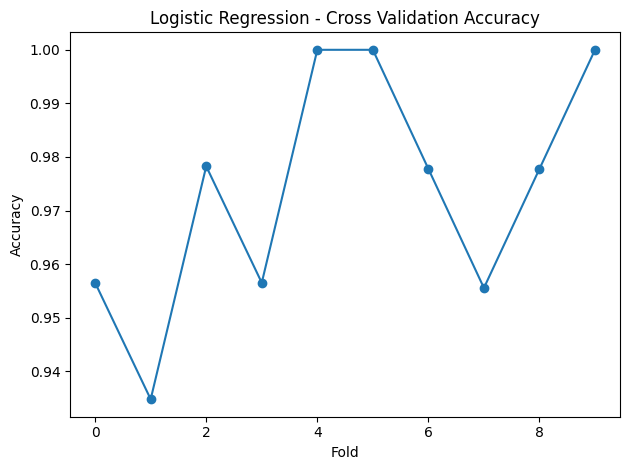

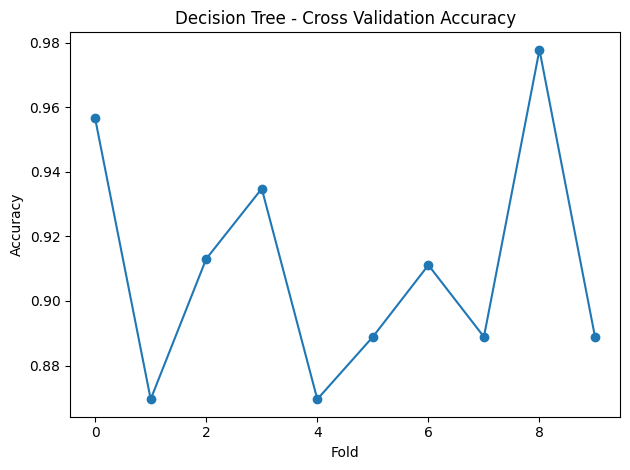

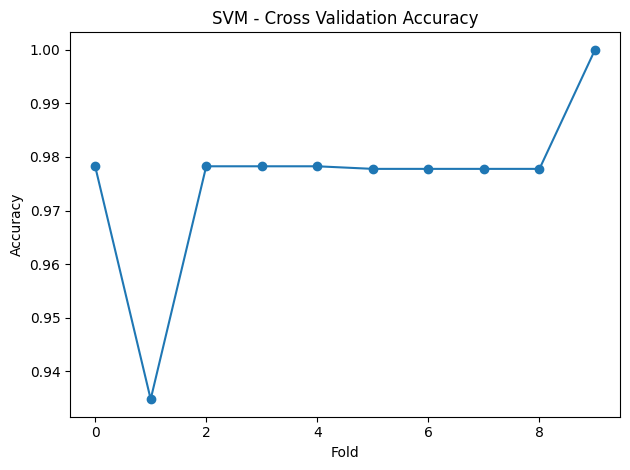

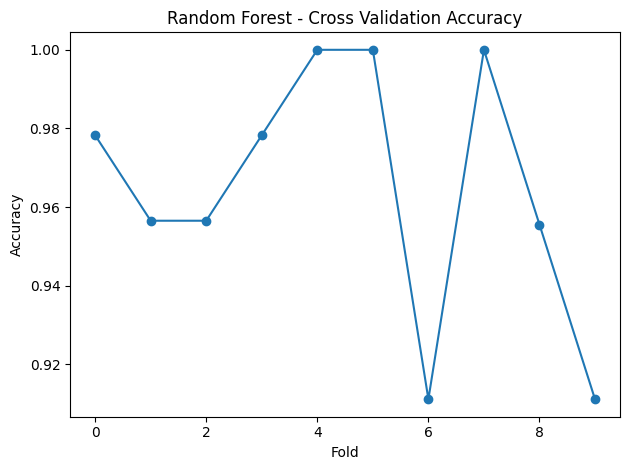

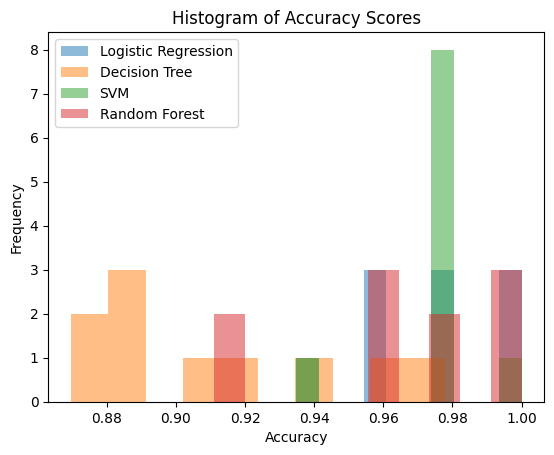

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import ttest_rel

data = load_breast_cancer()
X = data.data
y = data.target

print("Dataset Shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipelines = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000))
    ]),

    "Decision Tree": Pipeline([
        ('scaler', StandardScaler()),
        ('model', DecisionTreeClassifier())
    ]),

    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC())
    ]),

    "Random Forest": Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier())
    ])
}

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

results = {}

print("\nCross-Validation Results:")
for name, model in pipelines.items():
    scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    results[name] = scores
    print(f"{name}: Mean={scores.mean():.4f}, Std={scores.std():.4f}")

print("\nTest Set Evaluation:")
for name, model in pipelines.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

print("\nStatistical Comparison (Paired t-test):")

models = list(results.keys())

for i in range(len(models)):
    for j in range(i+1, len(models)):
        t_stat, p_val = ttest_rel(results[models[i]], results[models[j]])
        print(f"{models[i]} vs {models[j]}: p-value = {p_val:.4f}")
for name, scores in results.items():
    plt.figure()
    plt.plot(scores, marker='o')
    plt.title(f"{name} - Cross Validation Accuracy")
    plt.xlabel("Fold")
    plt.ylabel("Accuracy")
    plt.tight_layout()
    plt.show()
plt.figure()
for name, scores in results.items():
    plt.hist(scores, alpha=0.5, label=name)

plt.title("Histogram of Accuracy Scores")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.legend()
plt.show()

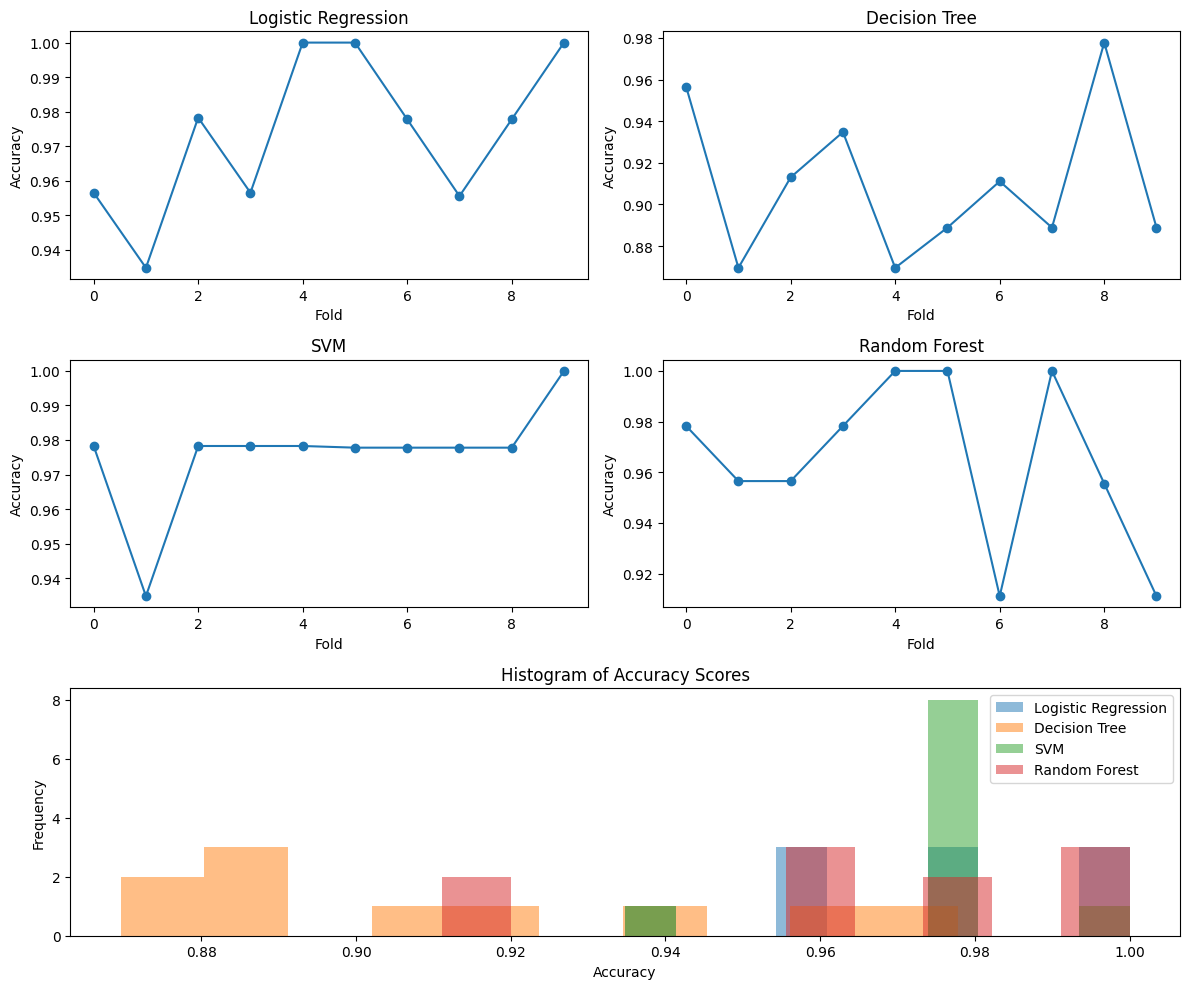

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

# 1. Logistic Regression
plt.subplot(3, 2, 1)
plt.plot(results["Logistic Regression"], marker='o')
plt.title("Logistic Regression")
plt.xlabel("Fold")
plt.ylabel("Accuracy")

# 2. Decision Tree
plt.subplot(3, 2, 2)
plt.plot(results["Decision Tree"], marker='o')
plt.title("Decision Tree")
plt.xlabel("Fold")
plt.ylabel("Accuracy")

# 3. SVM
plt.subplot(3, 2, 3)
plt.plot(results["SVM"], marker='o')
plt.title("SVM")
plt.xlabel("Fold")
plt.ylabel("Accuracy")

# 4. Random Forest
plt.subplot(3, 2, 4)
plt.plot(results["Random Forest"], marker='o')
plt.title("Random Forest")
plt.xlabel("Fold")
plt.ylabel("Accuracy")

# 5. Histogram (Full Width)
plt.subplot(3, 1, 3)
for name, scores in results.items():
    plt.hist(scores, alpha=0.5, label=name)

plt.title("Histogram of Accuracy Scores")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

   StudyHours  Attendance  Resources  Extracurricular  Motivation  Internet  \
0          19          64          1                0           0         1   
1          19          64          1                0           0         1   
2          19          64          1                0           0         1   
3          19          64          1                1           0         1   
4          19          64          1                1           0         1   

   Gender  Age  LearningStyle  OnlineCourses  Discussions  \
0       0   19              2              8            1   
1       0   23              3             16            0   
2       0   28              1             19            0   
3       0   19              2              8            1   
4       0   23              3             16            0   

   AssignmentCompletion  ExamScore  EduTech  StressLevel  FinalGrade  
0                    59         40        0            1           3  
1               

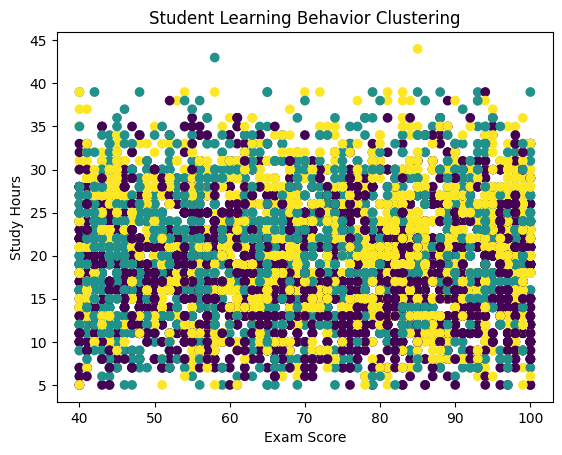

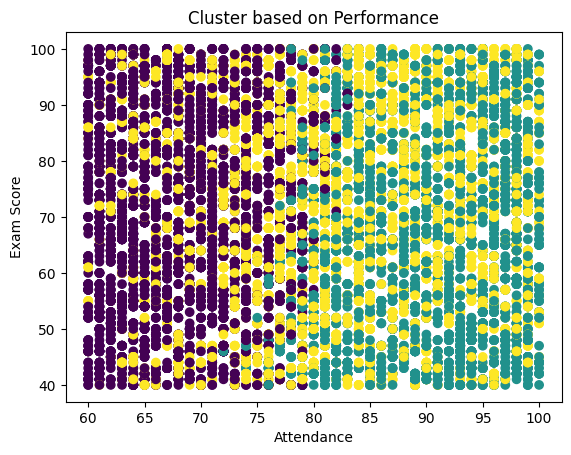

Project Completed Successfully!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("/content/student_performance.csv")
print(df.head())
df = df.dropna()
student_data = df[['StudyHours', 'Attendance', 'AssignmentCompletion', 'ExamScore']]
scaler = StandardScaler()
scaled_data = scaler.fit_transform(student_data)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_data)
print("\nClustered Data:\n")
print(df.head())
plt.scatter(df['ExamScore'], df['StudyHours'], c=df['Cluster'])
plt.xlabel("Exam Score")
plt.ylabel("Study Hours")
plt.title("Student Learning Behavior Clustering")
plt.show()
plt.scatter(df['Attendance'], df['ExamScore'], c=df['Cluster'])
plt.xlabel("Attendance")
plt.ylabel("Exam Score")
plt.title("Cluster based on Performance")
plt.show()
print("Project Completed Successfully!")